# Titanic Survival Prediction Pipeline

This notebook builds an end-to-end machine learning pipeline to predict passenger survival on the Titanic dataset.

The main goals are:
- Understand the dataset with EDA
- Identify missing values and feature types
- Apply preprocessing with Scikit-learn Pipeline
- Train a baseline classification model
- Evaluate model performance

### 1. Import Libraries

We import the required libraries for data analysis, visualization, preprocessing, model training, and evaluation.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

### 2. Load Dataset

We load the Titanic dataset from Seaborn. The target variable is `survived`, which indicates whether a passenger survived or not.

- `0`: did not survive
- `1`: survived

In [3]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### 3. Initial Data Inspection

Before building a model, we inspect the dataset structure.

This helps us understand:
- Number of rows and columns
- Data types
- Missing values
- Numerical feature distributions

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [5]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [6]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Initial Observations

From the initial inspection:

- The dataset has 891 rows.
- The target variable is `survived`.
- `age` has missing values.
- `embarked` has a small number of missing values.
- `deck` has many missing values, so it may not be useful for modeling.
- `alive` contains the same information as `survived`, so using it would cause data leakage.
- `fare` has a high maximum value compared to its mean, which may indicate outliers.

### 4. Feature Selection

We select features that may help predict survival.

We exclude:
- `alive`: because it directly reveals the target variable and causes data leakage
- `deck`: because it has too many missing values
- `class`: because it contains similar information to `pclass`
- `embark_town`: because it overlaps with `embarked`

In [8]:
features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

target = "survived"

X = df[features]
y = df[target]

In [9]:
X.head()

,pclass,sex,age,sibsp,parch,fare,embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [10]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64

### 5. Define Numerical and Categorical Features

Different feature types require different preprocessing steps.

Numerical features:
- Missing values will be filled with the median.
- Features will be scaled using StandardScaler.

Categorical features:
- Missing values will be filled with the most frequent value.
- Categories will be converted into numerical format using OneHotEncoder.

In [11]:
numeric_features = [
    "age",
    "fare",
    "sibsp",
    "parch"
]

categorical_features = [
    "sex",
    "embarked",
    "pclass"
]

### 6. Build Preprocessing Pipelines

We create separate preprocessing pipelines for numerical and categorical features.

For numerical features:
- Missing values are filled with the median.
- Features are scaled using StandardScaler.

For categorical features:
- Missing values are filled with the most frequent category.
- Categories are encoded using OneHotEncoder.

In [12]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [13]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

### 7. Combine Preprocessing Steps

ColumnTransformer allows us to apply different preprocessing steps to different feature groups.

- Numerical columns use the numerical pipeline.
- Categorical columns use the categorical pipeline.

In [14]:
preprocessor = ColumnTransformer(transformers = [
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

### 8. Train/Test Split

We split the data into training and test sets.

The model learns from the training set and is evaluated on the test set.

Because this is a classification problem, we use `stratify=y` to preserve the class distribution in both train and test sets.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

In [16]:
print("Training set size: ", X_train.shape)
print("Test set size: ", X_test.shape)

Training set size:  (712, 7)
Test set size:  (179, 7)


### 9. Build the Full Machine Learning Pipeline

We combine:
- preprocessing steps
- machine learning model

into a single pipeline.

This approach:
- keeps the workflow organized
- prevents data leakage
- improves reproducibility
- makes the project more production-ready

In [36]:
full_pipeline = Pipeline(steps = [
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
))
])

### 10. Train the Model

We train the pipeline on the training data.

During training:
- preprocessing steps are fitted only on the training set
- the model learns patterns from the processed data

This helps prevent data leakage.

In [37]:
full_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

### 11. Make Predictions

We use the trained pipeline to predict survival on the test set.

In [38]:
y_pred = full_pipeline.predict(X_test)

### 12. Evaluate Model Performance

We evaluate the model using:
- Accuracy Score
- Confusion Matrix
- Classification Report

In [39]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score: ", accuracy)

Accuracy Score:  0.8100558659217877


In [40]:
conf_matrix = confusion_matrix(y_test, y_pred)

print(conf_matrix)

[[91 19]
 [15 54]]


In [41]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.83      0.84       110
           1       0.74      0.78      0.76        69

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



### Final Observations

The pipeline successfully:
- handled missing values
- encoded categorical variables
- scaled numerical features
- trained a Logistic Regression model
- evaluated prediction performance

This project demonstrates a complete end-to-end machine learning workflow using Scikit-learn Pipelines.

### 13. Model Comparison

In this section, we compare three classification models using the same preprocessing pipeline:

- Logistic Regression
- Random Forest
- XGBoost

The goal is to evaluate which model performs better on the Titanic survival prediction task.

In [43]:
models = {
    "Logistic Regression": LogisticRegression(
    max_iter=1000,
    class_weight="balanced"),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
}

In [44]:
results = []

for model_name, model in models.items():
    model_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    model_pipeline.fit(X_train, y_train)
    
    y_pred = model_pipeline.predict(X_test)
    y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1]
    
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": classification_report(y_test, y_pred, output_dict=True)["1"]["precision"],
        "Recall": classification_report(y_test, y_pred, output_dict=True)["1"]["recall"],
        "F1-Score": classification_report(y_test, y_pred, output_dict=True)["1"]["f1-score"],
        "ROC-AUC": roc_auc_score(y_test, y_pred_proba)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.810056,0.739726,0.782609,0.760563,0.846377
1,Random Forest,0.810056,0.786885,0.695652,0.738462,0.840184
2,XGBoost,0.804469,0.757576,0.724638,0.740741,0.809025


### Model Comparison Observations

- All three models achieved similar performance.
- Logistic Regression achieved the highest precision and ROC-AUC score.
- Random Forest achieved the highest accuracy.
- XGBoost achieved the highest recall, meaning it captured more actual survivors.
- The Titanic dataset appears to contain relatively simple and strong predictive patterns, allowing even a baseline Logistic Regression model to perform well.

Overall, Random Forest and XGBoost slightly improved recall and F1-score, while Logistic Regression remained highly competitive as a simple and interpretable baseline model.

### 14. Final Model Evaluation

In [ ]:
final_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
))
])

final_pipeline.fit(X_train, y_train)

y_pred = final_pipeline.predict(X_test)

In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [27]:
conf_matrix = confusion_matrix(y_test, y_pred)

print(conf_matrix)

[[98 12]
 [23 46]]


### Classification Report Interpretation

- The model achieved an overall accuracy of approximately 80%.
- Class `0` (did not survive) achieved higher recall, meaning the model was better at identifying passengers who did not survive.
- Class `1` (survived) achieved lower recall, indicating that some actual survivors were missed by the model.
- Precision for class `1` remained relatively strong, suggesting that when the model predicted survival, it was often correct.
- The performance difference between the two classes may be influenced by class imbalance in the dataset.

Overall, the Logistic Regression model provided strong baseline performance while remaining simple and interpretable.

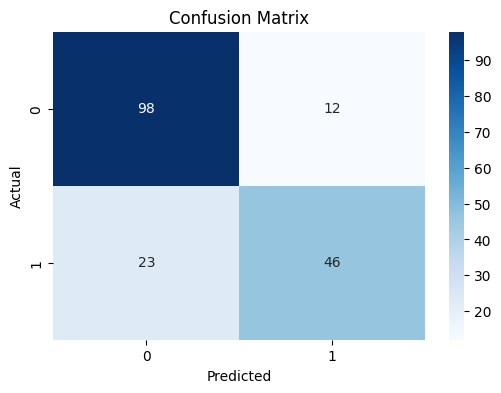

In [28]:
plt.figure(figsize=(6,4))

sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("../images/confusion_matrix.png")

plt.show()

In [29]:
import joblib
import os

model_path = r"C:\Users\melek\Desktop\My Documents\study-program\titanic-ml-pipeline\src\titanic_model.pkl"

os.makedirs(os.path.dirname(model_path), exist_ok=True)

joblib.dump(final_pipeline, model_path)

print("Model saved:", model_path)

Model saved: C:\Users\melek\Desktop\My Documents\study-program\titanic-ml-pipeline\src\titanic_model.pkl


## EDA
### Gender vs Survival
Survival Rate by Gender

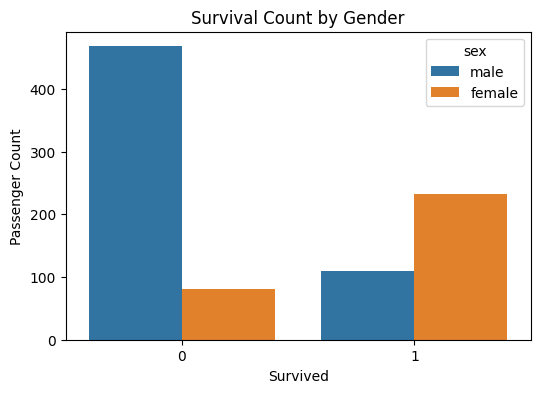

<Figure size 640x480 with 0 Axes>

In [33]:
import os
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="survived",
    hue="sex"
)

plt.title("Survival Count by Gender")
plt.xlabel("Survived")
plt.ylabel("Passenger Count")

plt.show()

os.makedirs("../images", exist_ok=True)

plt.savefig(
    "../images/survival_by_gender.png",
    bbox_inches="tight"
)

The visualization shows a strong relationship between gender and survival outcome. Female passengers had a substantially higher survival rate compared to male passengers, indicating that gender is an important predictive feature in the Titanic dataset.

### Age Distribution
Age Distribution by Survival

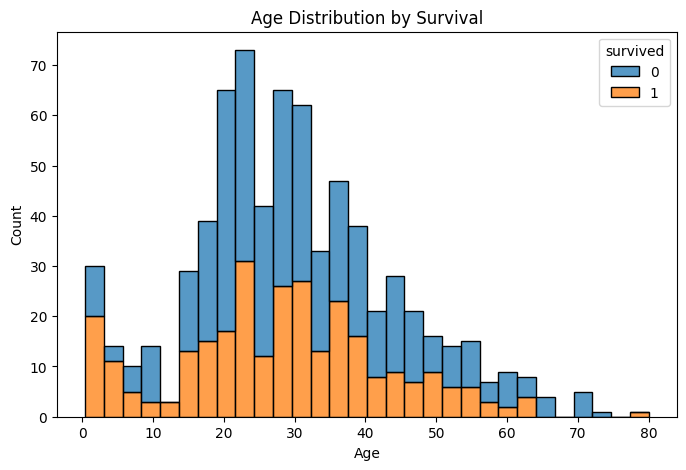

<Figure size 640x480 with 0 Axes>

In [34]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="age",
    hue="survived",
    multiple="stack",
    bins=30
)

plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

plt.savefig(
    "../images/age_distribution.png",
    bbox_inches="tight"
)

Younger passengers appeared to have slightly higher survival rates, although survival outcomes varied across all age groups.

### Passenger Class vs Survival
Survival Rate by Passenger Class

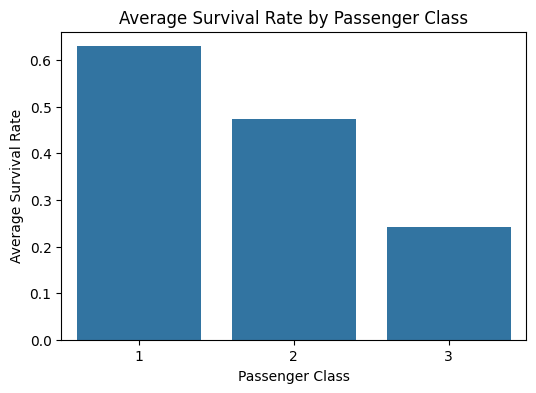

<Figure size 640x480 with 0 Axes>

In [35]:
survival_by_class = (
    df.groupby("pclass")["survived"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6,4))

sns.barplot(
    data=survival_by_class,
    x="pclass",
    y="survived"
)

plt.title("Average Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Average Survival Rate")

plt.show()

plt.savefig(
    "../images/survival_by_class.png",
    bbox_inches="tight"
)

Passengers in higher classes had significantly higher survival rates. First-class passengers were more likely to survive than third-class passengers.